<a href="https://colab.research.google.com/github/GustavoFA/IA376/blob/main/A1/236249_a1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA376 — Deep Generative Modeling

## A1 — Building a Model for the Synthesis of Tabular Healthcare Data

Gustavo Freitas Alves

236249

### Execice summary

In this activity I've to generate a synthetic database of blood count test results. The database contains 1000 fictitious **platelet** test results.

To achieve this, I selected real platelet exam data and used a probability density function (PDF) to generate my synthetic data. To verify whether the synthetic data resembles the real data, I used Kernel Density Estimation (KDE), the Cumulative Distribution Function (CDF) and the Kolmogorov-Smirnov Test.

Below, you can find my code with explanations.



### Imports

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import norm, ks_2samp

### Getting the clinical laboratory test results (in json extension)

To work with the raw data, I used a Python code (available on my GitHub - accessible through this [link](https://github.com/GustavoFA/IA376/blob/main/A1/csv2json.py)). In summary,  the script reads the CSVs files and converts them into a JSON file, ornanizing the data in the following structure:

```
{
    "patient_id": {
        "date": "2019-04-07 13:36:00",
        "sex": "M",
        "age": 38,
        "exams": {
            "PLAQUETAS SANGUE": 282.0,
            "NEUTRÓFILOS ABSOLUTO": 5.8476,
            "LINFÓCITOS ABSOLUTO": 3.1896,
            "NEUTRÓFILOS %": 44.0,
            "LINFÓCITOS %": 24.0
        }
    },
    .
    .
    .
}

```


In [2]:
!pip install -q gdown

In [3]:
!gdown 1t_2rnFzTUDS851VgfgPutB2pPUSEo_0e

Downloading...
From: https://drive.google.com/uc?id=1t_2rnFzTUDS851VgfgPutB2pPUSEo_0e
To: /content/data.json
100% 10.2M/10.2M [00:00<00:00, 171MB/s]


In [4]:
with open('data.json', 'r') as f:
  data = json.load(f)

## Exploring blood data

In [5]:
exam_counter = Counter()

Checking the number of types of exams.

In [6]:
for patient in data.values():
  exams = patient['exams']
  exam_counter.update(exams.keys())
print(f'Number of exams: {len(exam_counter)}')

Number of exams: 17


Showing all the exams and their respective values.

In [7]:
exam_df = pd.DataFrame(
    exam_counter.items(),
    columns=['exam', 'count']
)
exam_df = exam_df.sort_values(by='count', ascending=False)
exam_df.head(30)

,exam,count
0,PLAQUETAS SANGUE,30912
1,NEUTRÓFILOS ABSOLUTO,30912
2,LINFÓCITOS ABSOLUTO,30912
4,LINFÓCITOS %,30912
3,NEUTRÓFILOS %,30872
5,LEUCÓCITOS TOTAIS,216
6,MCHC,216
7,EOSINÓFILOS ABSOLUTO,216
8,LUC ABSOLUTO,216
9,NEUTRÓFILOS SEGMENTADOS %,216


So, in the table above we can see that the most common exams are *PLAQUETAS SANGUE*, *NEUTRÓFILOS ABSOLUTO*, *LINFÓCITOS ABSOLUTO*, *LINFÓCITOS*,
*NEUTRÓFILOS* and *LEUCÓCITOS TOTAIS*.

For this activity I'll use the **PLAQUETAS SANGUE** data for generate synthetic database, because it has a big number of samples.

## Generate a synthetic database using normal distribution (Gaussian)

### Selecting data exam

In [8]:
# Chosen exam
exam_choice = "PLAQUETAS SANGUE"

In [9]:
# All the sample values
exam_values = [patient['exams'][exam_choice] for patient in data.values() if exam_choice in patient['exams']]

In [10]:
# I turned the data into a pandas DataFrame because it's easier to manipulate and analyse.
samples_db = pd.DataFrame({f"{exam_choice.lower()}": exam_values})
samples_db.head()

,plaquetas sangue
0,282.0
1,377.0
2,300.0
3,215.0
4,359.0


In [11]:
print(f'Total number of samples in database: {len(samples_db)}')

Total number of samples in database: 30912


### Cleaning data

Remove missing values

In [12]:
samples_db_cleaned = samples_db.dropna()
print(f'Number of samples in database after removing missing values: {len(samples_db_cleaned)}')

Number of samples in database after removing missing values: 30907


Remove outliers using the Interquartile range method (IQR).

In [13]:
q1 = samples_db_cleaned[exam_choice.lower()].quantile(0.25)
q3 = samples_db_cleaned[exam_choice.lower()].quantile(0.75)

In [14]:
iqr = q3 - q1

In [15]:
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr

In [16]:
samples_db_cleaned = samples_db_cleaned[(samples_db_cleaned[exam_choice.lower()] > iqr_lower) & (samples_db_cleaned[exam_choice.lower()] < iqr_upper)]
print(f'Number of samples in database after removing outliers: {len(samples_db_cleaned)}')

Number of samples in database after removing outliers: 29711


In [17]:
# return the main database as the cleaned database
samples_db = samples_db_cleaned

### Analysing filtered data

In [18]:
samples_db.describe()

,plaquetas sangue
count,29711.000000
mean,241.520171
std,78.998385
min,30.000000
25%,190.000000
50%,238.000000
75%,292.000000
max,460.000000


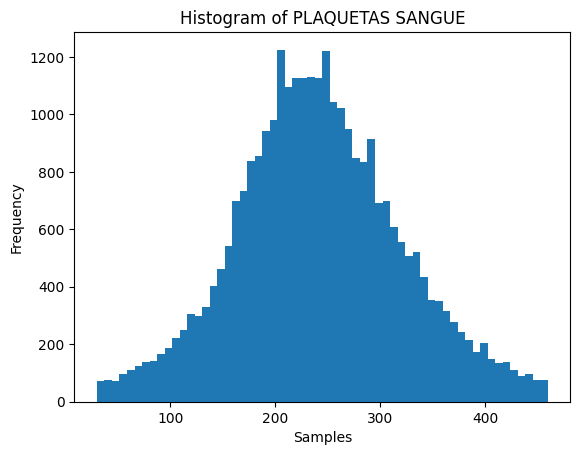

In [19]:
plt.hist(samples_db[exam_choice.lower()], bins=60)
plt.title(f"Histogram of {exam_choice}")
plt.ylabel("Frequency")
plt.xlabel("Samples")
plt.show()

Looking at the histogram above, we can see that the data follows a normal distribution.

### Fitting the data

As discussed before, I will use the normal (Gaussian) distribution to generate my synthetic data. For this, I need to compute the parameters of the probability density function (PDF), the mean (μ) and the standard deviation (σ), to solve the equation below:

$$f(x) = \frac{1}{\sqrt{2\pi σ^2}}exp(-\frac{(x-μ)^2}{2σ^2})$$

In [20]:
# Compute the parameters
mu, sigma = norm.fit(samples_db[exam_choice.lower()])

In [21]:
x = np.linspace(samples_db[exam_choice.lower()].min(), samples_db[exam_choice.lower()].max(), 200)
# Compute the pdf
pdf = norm.pdf(x, mu, sigma)

Plotting the samples and the PDF

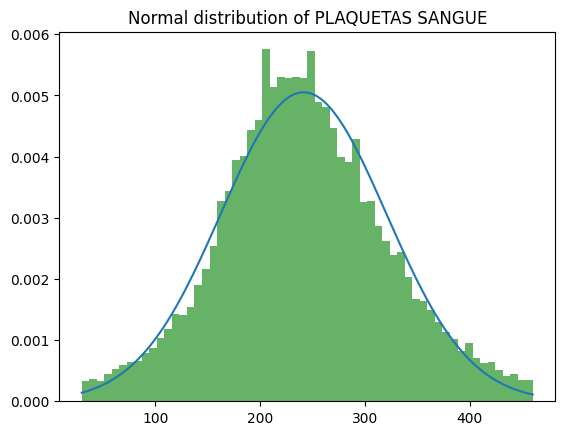

In [22]:
plt.hist(samples_db[exam_choice.lower()], bins=60, density=True, alpha=0.6, color='g')
plt.plot(x, pdf)
plt.title(f"Normal distribution of {exam_choice}")
plt.show()

### Generate synthetic dataset

Generate a synthetic dataset following the normal distribution.

In [23]:
# Create random values using the normal distribution parameters computed previously
synthetic_dataset = np.random.normal(mu, sigma, 1000)

Check if there is unrealistic values

In [24]:
# Considering our original platelets database, I replace each value that is smaller than the minimum or it is larger than the maximum.
synthetic_dataset = np.clip(
    synthetic_dataset,
    samples_db[exam_choice.lower()].min(),
    samples_db[exam_choice.lower()].max()
)

Create the final synthetic dataset with 1000 samples.

In [25]:
synthetic_dataset = pd.DataFrame({f"{exam_choice.lower()}": synthetic_dataset})

In [26]:
print(f'Number of samples in synthetic dataset: {len(synthetic_dataset)}')

Number of samples in synthetic dataset: 1000


### Compare real and synthetic data

First comparison uses a histogram.

From the graph below, we can see that both datasets have the same shape, roughly following the same PDF. However, we can observe a difference in density in the middle range of sample values, where the synthetic data presents a larger number of samples than the real data.

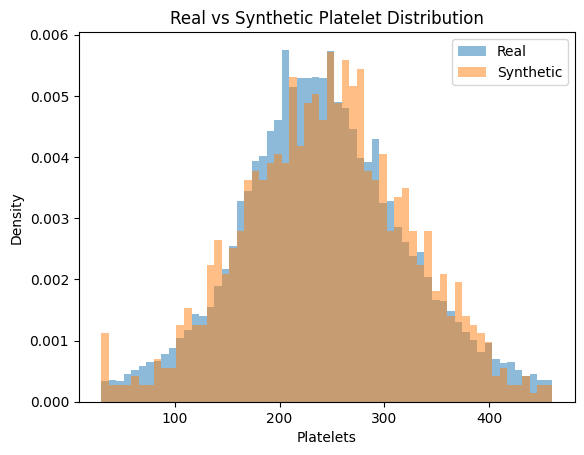

In [27]:
plt.hist(samples_db[exam_choice.lower()], bins=60, density=True, alpha=0.5, label="Real")
plt.hist(synthetic_dataset[exam_choice.lower()], bins=60, density=True, alpha=0.5, label="Synthetic")
plt.title("Real vs Synthetic Platelet Distribution")
plt.xlabel("Platelets")
plt.ylabel("Density")
plt.legend()
plt.show()

Comparison using Kernel Density Estimation (KDE).

From the graph below, we can confirm the same behavior observed in the histogram above. Both datasets have roughly the same shape.

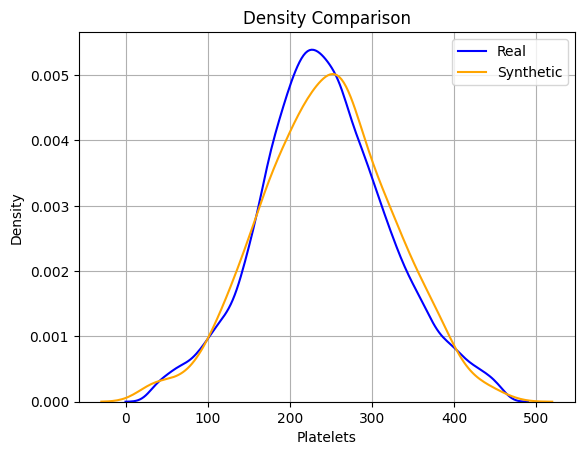

In [28]:
sns.kdeplot(samples_db[exam_choice.lower()], label="Real", color='blue')
sns.kdeplot(synthetic_dataset[exam_choice.lower()], label="Synthetic", color='orange')
plt.title("Density Comparison")
plt.xlabel("Platelets")
plt.legend()
plt.grid()
plt.show()

Cumulative Distribution Function (CDF) comparison.

From the CDF graph below, we can observe the both datasets have similar distribution and variability.

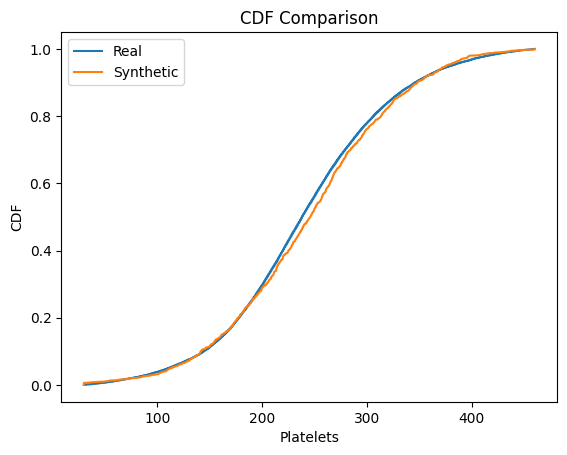

In [29]:
real = np.sort(samples_db[exam_choice.lower()])
synthetic = np.sort(synthetic_dataset[exam_choice.lower()])

real_cdf = np.arange(len(real)) / len(real)
syn_cdf = np.arange(len(synthetic)) / len(synthetic)

plt.plot(real, real_cdf, label="Real")
plt.plot(synthetic, syn_cdf, label="Synthetic")
plt.title("CDF Comparison")
plt.xlabel("Platelets")
plt.ylabel("CDF")
plt.legend()
plt.show()

Kolmogorov-Smirnov Test.

The KS statistic measures the largest vertical gap between those curves. The KS value below, demonstrade the both curves are very similar. The p-value is greater than 0.05, so we can considere that both samples come from the same distribution.



In [30]:
ks_stat, p_value = ks_2samp(samples_db[exam_choice.lower()], synthetic_dataset[exam_choice.lower()])
print(f'KS Statistic: {ks_stat:.4f}')
print(f'P-value: {p_value:.2f}')

KS Statistic: 0.0448
P-value: 0.04


Mean and standard deviation

In [31]:
print(f'Real data mean: {samples_db[exam_choice.lower()].mean():.2f}')
print(f'Real data std: {samples_db[exam_choice.lower()].std():.2f}')
print(f'Synthetic data mean: {synthetic_dataset[exam_choice.lower()].mean():.2f}')
print(f'Synthetic data std: {synthetic_dataset[exam_choice.lower()].std():.2f}')

Real data mean: 241.52
Real data std: 79.00
Synthetic data mean: 244.29
Synthetic data std: 79.23


### **Is synthetic data realistic?**

Considering the results presented below, we can confirm the **synthetic data is realistic**, because the synthetic data is extremly proximity to the real data distribution.

# Extra

Now, I will reproduce the same process as before, but for the following exams: PLAQUETAS SANGUE, NEUTRÓFILOS ABSOLUTO, LINFÓCITOS ABSOLUTO, NEUTRÓFILOS, and LINFÓCITOS.

### Get data

Use the same JSON file data.

In [4]:
with open('data.json', 'r') as f:
  data2 = json.load(f)

In [5]:
df_all_exams = pd.DataFrame(
    [patient['exams'] for patient in data2.values()]
)

### Filter data

We selected the main exams and cleaned the data using the same approaches as before, such as removing NaN values and applying the IQR method.

In [6]:
selected_exams = [
    "PLAQUETAS SANGUE",
    "NEUTRÓFILOS ABSOLUTO",
    "LINFÓCITOS ABSOLUTO",
    "NEUTRÓFILOS %",
    "LINFÓCITOS %"
]

In [7]:
df_cleaned = df_all_exams[selected_exams].copy()

In [8]:
df_cleaned = df_cleaned.dropna()

In [9]:
for column in df_cleaned.columns:
  q1 = df_cleaned[column].quantile(0.25)
  q3 = df_cleaned[column].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  df_cleaned[column] = df_cleaned[column].where(
      (df_cleaned[column] >= lower) & (df_cleaned[column] <= upper)
  )

### Fit data

Compute the mean and the standart deviation of the PDF.

In [10]:
pdf_params = {}
for column in df_cleaned.columns:
  # Double-check for NaN values, since they may cause issues during the computations.
  column_data = df_cleaned[column].dropna()
  # Verify that each column contains data to prevent errors from empty columns.
  if len(column_data) == 0:
    continue
  mu, sigma = norm.fit(column_data)
  pdf_params[column] = (mu, sigma)

### Generate data

Generate synthetic data using normal distribution.

In [11]:
all_synthetic_data = {}
for exam, (mu, sigma) in pdf_params.items():
  all_synthetic_data[exam] = np.random.normal(mu, sigma, 1000)

all_synthetic_df = pd.DataFrame(all_synthetic_data)

In [12]:
# Remove unrealistic values
for column in all_synthetic_df.columns:

    real_min = df_cleaned[column].min()
    real_max = df_cleaned[column].max()

    all_synthetic_df[column] = np.clip(
        all_synthetic_df[column],
        real_min,
        real_max
    )

### Evaluate data

Visually evaluate the behavior of the real and synthetic data.

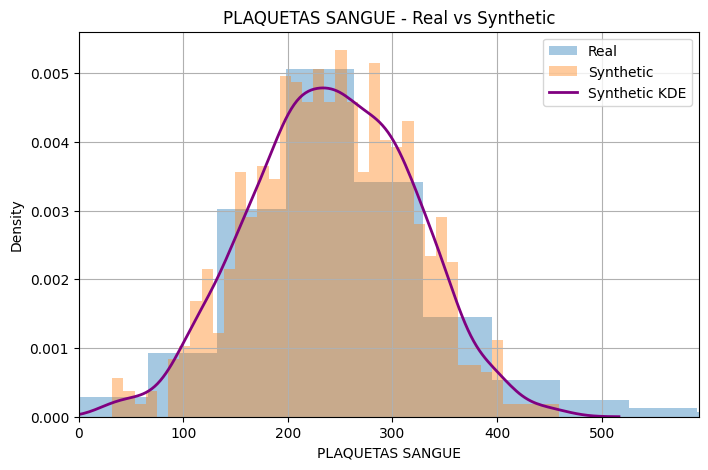

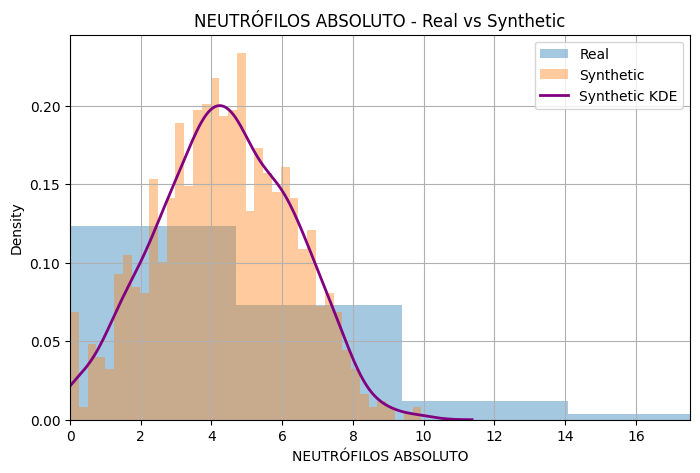

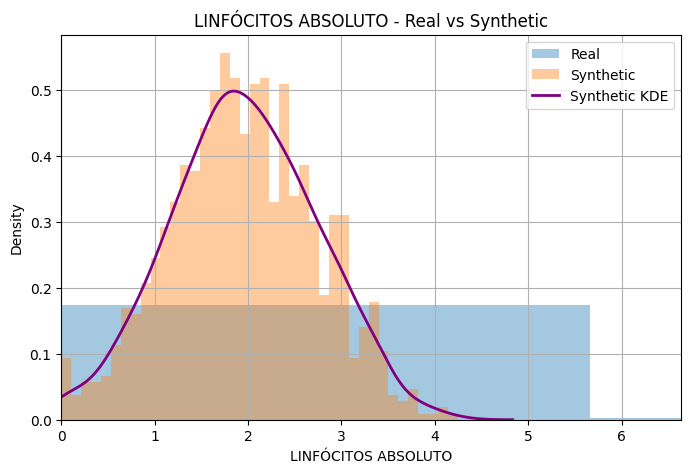

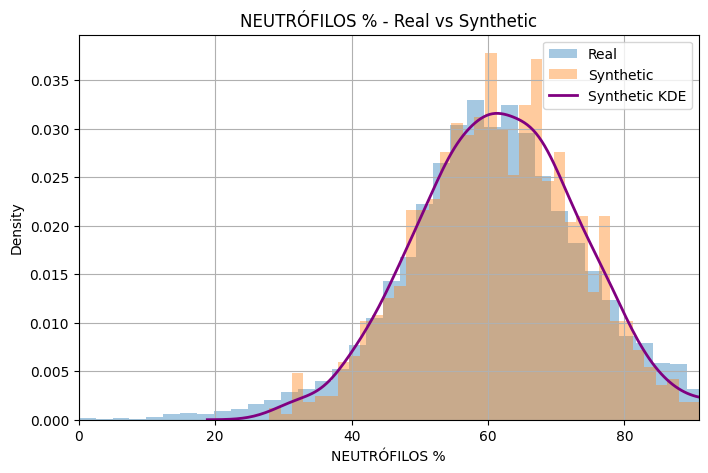

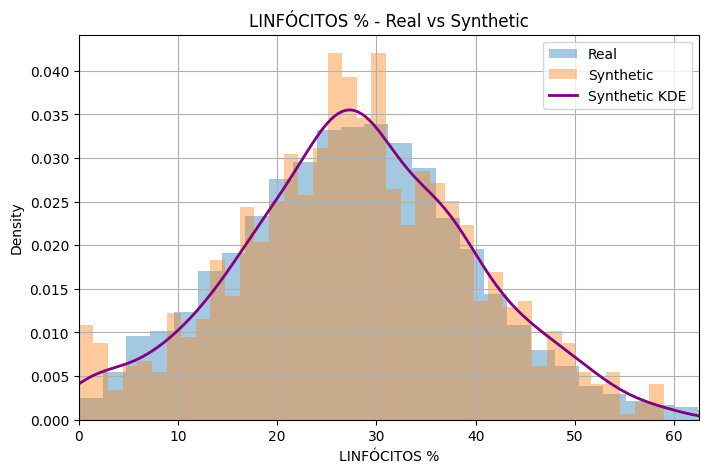

In [20]:
for column in all_synthetic_df.columns:

    real = df_all_exams[column].dropna()
    synthetic = all_synthetic_df[column].dropna()

    plt.figure(figsize=(8,5))

    # Histogram
    plt.hist(real, bins=40, density=True, alpha=0.4, label="Real")
    plt.hist(synthetic, bins=40, density=True, alpha=0.4, label="Synthetic")

    # KDE
    sns.kdeplot(synthetic, linewidth=2, color='purple', label='Synthetic KDE')

    plt.title(f"{column} - Real vs Synthetic")
    plt.xlabel(column)
    plt.ylabel("Density")

    upper = real.quantile(0.99)
    plt.xlim(0, upper)

    plt.legend()
    plt.grid()

    plt.show()

By looking at the graphs above, we can observe that our data generation method, which is based on a normal distribution, performs very well for data that follows this type of behavior.

However, for cases where the data does not follow a normal distribution, such as NEUTRÓFILOS ABSOLUTO and LINFÓCITOS ABSOLUTO, the generation function is not able to accurately reproduce the original distribution.

Therefore, for these cases, it's necessary to consider other types of distribution functions that better represent the behavior of the data.

Considering the field of synthetic data, selecting an appropriate statistical distribution is essential to ensure that the generated data preserves the main characteristics of the real dataset.